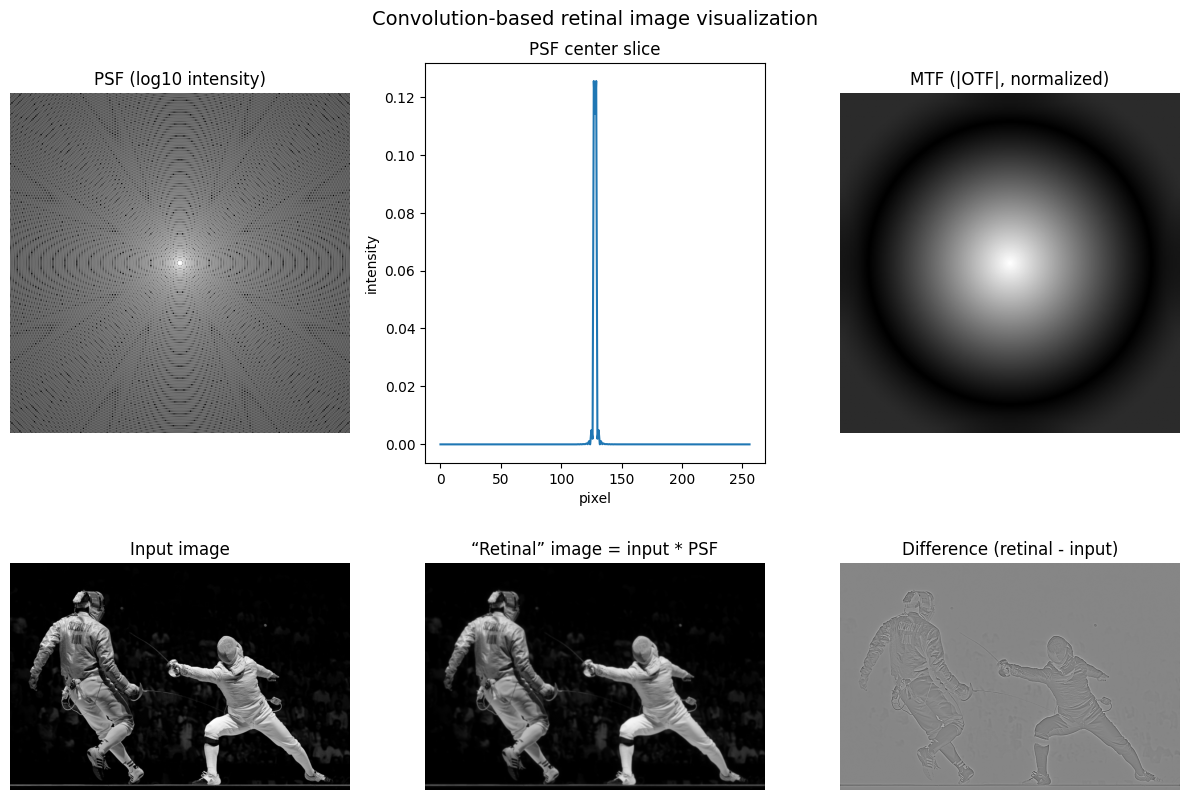

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import fftconvolve
from scipy.fft import fft2, fftshift
from scipy.special import j1  # Bessel J1 for Airy PSF
from PIL import Image


def load_grayscale(path, max_size=768):
    im = Image.open(path).convert("L")
    im.thumbnail((max_size, max_size))
    arr = np.asarray(im, dtype=np.float32) / 255.0
    return arr


def gaussian_psf(size=129, sigma_px=2.0):
    """Simple blur kernel; not physically perfect but very intuitive."""
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx**2 + yy**2) / (2 * sigma_px**2))
    h /= h.sum()
    return h


def airy_psf(size=257, airy_radius_px=3.0, eps=1e-12):
    """
    Diffraction-limited Airy PSF (monochromatic) in a convenient pixel-parameter form.

    airy_radius_px ~ first-zero radius in pixels (sets blur scale).
    """
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    r = np.sqrt(xx**2 + yy**2) + eps

    # Choose k so that first zero occurs at r = airy_radius_px.
    # First zero of J1 is at ~3.8317, and Airy amplitude uses 2*J1(x)/x.
    x = 3.8317 * (r / airy_radius_px)

    amp = 2 * j1(x) / (x + eps)
    h = amp**2
    h /= h.sum()
    return h


def convolve_image(image, psf):
    """FFT convolution; returns same-size result."""
    # fftconvolve returns full size unless we ask for 'same'
    return fftconvolve(image, psf, mode="same")


def show_results(I, h, title=""):
    Iret = convolve_image(I, h)
    diff = Iret - I

    # OTF / MTF
    H = fftshift(fft2(fftshift(h)))
    MTF = np.abs(H)
    MTF /= MTF.max() + 1e-12

    # PSF center slice
    c = h.shape[0] // 2
    psf_slice = h[c, :]

    fig = plt.figure(figsize=(12, 9))
    fig.suptitle(title, fontsize=14)

    # PSF (log)
    ax1 = plt.subplot(2, 3, 1)
    ax1.imshow(np.log10(h + 1e-12), cmap="gray")
    ax1.set_title("PSF (log10 intensity)")
    ax1.axis("off")

    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(psf_slice)
    ax2.set_title("PSF center slice")
    ax2.set_xlabel("pixel")
    ax2.set_ylabel("intensity")

    ax3 = plt.subplot(2, 3, 3)
    ax3.imshow(MTF, cmap="gray")
    ax3.set_title("MTF (|OTF|, normalized)")
    ax3.axis("off")

    ax4 = plt.subplot(2, 3, 4)
    ax4.imshow(I, cmap="gray", vmin=0, vmax=1)
    ax4.set_title("Input image")
    ax4.axis("off")

    ax5 = plt.subplot(2, 3, 5)
    ax5.imshow(Iret, cmap="gray", vmin=0, vmax=1)
    ax5.set_title("“Retinal” image = input * PSF")
    ax5.axis("off")

    ax6 = plt.subplot(2, 3, 6)
    ax6.imshow(diff, cmap="gray")
    ax6.set_title("Difference (retinal - input)")
    ax6.axis("off")

    plt.tight_layout()
    plt.show()


# --- Use it ---
# Replace with your own image file:
I = load_grayscale("/Users/elij/Desktop/Imagery/di-img/fencing.jpg")

h = airy_psf(size=257, airy_radius_px=2.2)   # try 1.5, 2.5, 4.0
# h = gaussian_psf(size=129, sigma_px=2.0)   # simpler alternative

show_results(I, h, title="Convolution-based retinal image visualization")
